In [8]:
import os

if os.path.exists("final_features.pkl"):
    os.remove("final_features.pkl")

In [9]:
!apt-get update -qq
!apt-get install git-lfs -y -qq
!git lfs install

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package git-lfs.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.


In [10]:
!git clone https://github.com/PENUMARTHIHIMAVARSHINI/Speech-Processing-Journal-Project.git

Cloning into 'Speech-Processing-Journal-Project'...
remote: Enumerating objects: 10866, done.
remote: Total 10866 (delta 0), reused 0 (delta 0), pack-reused 10866 (from 1)
Receiving objects: 100% (10866/10866), 1.19 GiB | 25.72 MiB/s, done.
Resolving deltas: 100% (1572/1572), done.
Updating files: 100% (8335/8335), done.
Filtering content: 100% (4219/4219), 1.30 GiB | 9.78 MiB/s, done.


In [14]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir(".")[:30])

print("\nSearching for final_features.pkl:")
for root, dirs, files in os.walk("."):
    if "final_features.pkl" in files:
        print("FOUND:", os.path.join(root, "final_features.pkl"))

Current directory:
/content

Files/folders here:
['.config', 'Speech-Processing-Journal-Project', 'sample_data']

Searching for final_features.pkl:
FOUND: ./Speech-Processing-Journal-Project/Speech Data/final_features.pkl


In [15]:
!git lfs ls-files

Not in a git repository.


In [16]:
%cd /content/Speech-Processing-Journal-Project

/content/Speech-Processing-Journal-Project


In [17]:
!git lfs ls-files

f8438e9fb1 * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-001/Processed_Patient_Audio/control/cookie/processed_audios/002-0/patient.wav
f075c463f6 * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-001/Processed_Patient_Audio/control/cookie/processed_audios/002-1/patient.wav
f318a23f54 * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-001/Processed_Patient_Audio/control/cookie/processed_audios/002-2/patient.wav
97badd48d3 * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-001/Processed_Patient_Audio/control/cookie/processed_audios/002-3/patient.wav
9ae7443226 * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-001/Processed_Patient_Audio/control/cookie/processed_audios/006-2/patient.wav
c797cde26a * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-001/Processed_Patient_Audio/control/cookie/processed_audios/006-3/patient.wav
ae47855874 * Speech Data/Dataset/Processed_Patient_Audio-20260808T064515Z-1-

In [18]:
!git lfs pull --include="Speech Data/final_features.pkl"

In [19]:
import os

pkl_path = "/content/Speech-Processing-Journal-Project/Speech Data/final_features.pkl"

print("File exists:", os.path.exists(pkl_path))
print("File size:", os.path.getsize(pkl_path), "bytes")

File exists: True
File size: 232669069 bytes


In [20]:
import pickle

pkl_path = "/content/Speech-Processing-Journal-Project/Speech Data/final_features.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

print("Type:", type(data))
print("Number of samples:", len(data))
print("First sample keys:", data[0].keys())

Type: <class 'list'>
Number of samples: 3262
First sample keys: dict_keys(['audio', 'text', 'features', 'label'])


In [21]:
print(data[0])

{'audio': '/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_0.wav', 'text': 'All right.', 'features': {'mel': array([[-26.60001   , -23.89701   , -20.037853  , ..., -30.628777  ,
        -33.480526  , -37.98611   ],
       [-12.276585  , -10.670434  ,  -9.021804  , ..., -22.941929  ,
        -28.737886  , -38.916424  ],
       [  0.37493762,   4.92518   ,   4.318761  , ..., -22.855667  ,
        -29.859924  , -33.27069   ],
       ...,
       [-56.05793   , -53.84718   , -51.84313   , ..., -50.35179   ,
        -47.909218  , -50.992035  ],
       [-56.911045  , -56.323326  , -55.338562  , ..., -53.684265  ,
        -56.64948   , -54.729862  ],
       [-56.159016  , -59.309998  , -59.7985    , ..., -59.793076  ,
        -59.7985    , -59.7985    ]], dtype=float32), 'mfcc': array([[-381.0374   , -359.2448   , -372.5139   , ..., -356.39917  ,
        -412.7389   , -459.27377  ],
       [ 164.26285  ,  163.1437   ,  153.57713  , ...,  131.09644  ,
         1

In [22]:
# Inspect the structure of the features field

print("Features type:", type(data[0]["features"]))

if isinstance(data[0]["features"], dict):
    print("Feature keys:")
    print(data[0]["features"].keys())
else:
    print("First feature object:")
    print(data[0]["features"])

Features type: <class 'dict'>
Feature keys:
dict_keys(['mel', 'mfcc', 'pitch', 'energy', 'pause_count', 'avg_pause', 'speech_rate', 'filler_count', 'repetition', 'turn_length', 'lexical_diversity', 'sentence_length', 'pos_distribution', 'bert', 'smile'])


In [23]:
# Inspect the first sample's feature structure in detail

from pprint import pprint

pprint(data[0]["features"])

{'avg_pause': np.float64(0.288),
 'bert': array([ 2.40872856e-02,  1.55083556e-02,  2.97416121e-01, -2.41609648e-01,
       -1.28370449e-01, -3.35797966e-01,  2.23500401e-01,  4.44161803e-01,
       -1.68693066e-02, -1.89544648e-01, -1.79923326e-01, -4.93183792e-01,
        6.81644529e-02,  4.64799166e-01, -3.38248432e-01, -1.78683087e-01,
        6.86582401e-02, -4.20734882e-01, -1.06364131e-01,  1.79900303e-01,
        1.21884957e-01, -1.15141705e-01, -1.33348824e-02,  3.01857889e-01,
        3.49048764e-01, -1.27109541e-02, -1.83387235e-01, -3.06576788e-01,
       -2.80696690e-01,  6.44117072e-02,  2.00572416e-01, -2.01370120e-01,
       -8.97131920e-01,  3.78116608e-01,  1.30255178e-01,  9.91183147e-02,
        2.51076519e-01,  6.03101790e-01, -6.36446118e-01, -4.78501897e-03,
       -2.61687100e-01,  9.03326720e-02,  7.38692135e-02,  4.03521538e-01,
        2.32441857e-01, -2.64025450e-01,  2.81365305e-01, -1.76437013e-02,
        2.08068281e-01, -6.57946587e-01,  1.45373002e-01, 

In [24]:
import numpy as np

smile = np.asarray(data[0]["features"]["smile"])
bert = np.asarray(data[0]["features"]["bert"])

print("SMILE shape:", smile.shape)
print("SMILE dimensions:", smile.ndim)

print("BERT shape:", bert.shape)
print("BERT dimensions:", bert.ndim)

SMILE shape: (6373,)
SMILE dimensions: 1
BERT shape: (768,)
BERT dimensions: 1


In [25]:
from collections import Counter

print("Labels:", Counter(item["label"] for item in data))

print("\nFirst 10 audio paths:")
for item in data[:10]:
    print(item["audio"])

print("\nFirst 10 BERT shapes:")
for item in data[:10]:
    print(np.asarray(item["features"]["bert"]).shape)

Labels: Counter({1: 2528, 0: 734})

First 10 audio paths:
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_0.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_1.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_2.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_3.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_4.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_5.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-0/seg_6.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-2/seg_0.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-2/seg_1.wav
/content/drive/MyDrive/Segmented_Data/dementia/cookie/processed_audios/001-2/seg_2.wav

First 10 BERT shapes:
(768,)
(768,)
(768,)
(768,)
(768,)
(768,)
(768,)


In [26]:
import os
from collections import defaultdict

recordings = defaultdict(list)

for item in data:
    audio_path = item["audio"]

    # Get the recording folder, e.g. 001-0
    recording_id = os.path.basename(os.path.dirname(audio_path))

    recordings[recording_id].append(item)

print("Number of recordings:", len(recordings))

print("\nFirst 10 recordings:")
for recording_id, items in list(recordings.items())[:10]:
    print(
        recording_id,
        "segments =", len(items),
        "label =", items[0]["label"]
    )

Number of recordings: 501

First 10 recordings:
001-0 segments = 18 label = 1
001-2 segments = 18 label = 1
005-0 segments = 8 label = 1
010-0 segments = 11 label = 1
010-1 segments = 10 label = 1
010-2 segments = 20 label = 1
010-4 segments = 14 label = 1
014-2 segments = 2 label = 1
016-0 segments = 12 label = 1
016-1 segments = 9 label = 1


In [27]:
import numpy as np
import pandas as pd
import os
from collections import defaultdict

# Group samples by recording
recordings = defaultdict(list)

for item in data:
    recording_id = os.path.basename(os.path.dirname(item["audio"]))
    recordings[recording_id].append(item)

temporal_rows = []

for recording_id, items in recordings.items():

    # Sort by segment number
    items = sorted(
        items,
        key=lambda x: int(
            os.path.basename(x["audio"])
            .replace("seg_", "")
            .replace(".wav", "")
        )
    )

    # BERT embeddings
    embeddings = np.array([
        item["features"]["bert"]
        for item in items
    ])

    # Consecutive temporal changes
    if len(embeddings) > 1:
        distances = np.linalg.norm(
            np.diff(embeddings, axis=0),
            axis=1
        )

        drift = np.mean(distances)
    else:
        drift = np.nan

    temporal_rows.append({
        "Recording_ID": recording_id,
        "Label": items[0]["label"],
        "Drift": drift,
        "Num_Segments": len(items)
    })

temporal_df = pd.DataFrame(temporal_rows)

print("Number of recordings:", len(temporal_df))
display(temporal_df.head())

Number of recordings: 501


,Recording_ID,Label,Drift,Num_Segments
0,001-0,1,9.050593,18
1,001-2,1,8.505806,18
2,005-0,1,8.300906,8
3,010-0,1,9.092535,11
4,010-1,1,9.645352,10


In [28]:
print(temporal_df["Drift"].describe())
print("\nLabels:")
print(temporal_df["Label"].value_counts())

count    429.000000
mean       8.053483
std        0.882655
min        3.874121
25%        7.511343
50%        8.167531
75%        8.625162
max       10.257224
Name: Drift, dtype: float64

Labels:
Label
1    301
0    200
Name: count, dtype: int64


In [29]:
import numpy as np
import pandas as pd
import os
from collections import defaultdict

# ---------------------------------------------------------
# Group speech segments by recording
# ---------------------------------------------------------

recordings = defaultdict(list)

for item in data:
    recording_id = os.path.basename(os.path.dirname(item["audio"]))
    recordings[recording_id].append(item)


# ---------------------------------------------------------
# Calculate recording-level temporal features
# ---------------------------------------------------------

rows = []

for recording_id, items in recordings.items():

    # Sort segments chronologically
    items = sorted(
        items,
        key=lambda x: int(
            os.path.basename(x["audio"])
            .replace("seg_", "")
            .replace(".wav", "")
        )
    )

    embeddings = np.asarray([
        item["features"]["bert"]
        for item in items
    ])

    label = items[0]["label"]

    # Need at least two segments
    if len(embeddings) < 2:
        continue

    # -----------------------------------------------------
    # Pairwise temporal change
    # -----------------------------------------------------

    distances = np.linalg.norm(
        embeddings[1:] - embeddings[:-1],
        axis=1
    )

    # Mean temporal drift
    drift = np.mean(distances)

    # -----------------------------------------------------
    # Temporal consistency
    # Higher consistency = lower variation
    # -----------------------------------------------------

    consistency = np.exp(-np.std(distances))

    # -----------------------------------------------------
    # Combined cognitive instability
    # -----------------------------------------------------

    instability = drift * (1 - consistency)

    # -----------------------------------------------------
    # Breakdown
    # -----------------------------------------------------

    # Identify unusually large temporal changes
    threshold = np.mean(distances) + np.std(distances)

    breakdown_points = distances[distances > threshold]

    if len(breakdown_points) > 0:
        breakdown = np.mean(breakdown_points)
    else:
        breakdown = 0.0

    rows.append({
        "Recording_ID": recording_id,
        "Label": label,
        "Drift": drift,
        "Consistency": consistency,
        "Instability": instability,
        "Breakdown": breakdown,
        "Num_Segments": len(embeddings)
    })


temporal_df = pd.DataFrame(rows)

print("Temporal dataset shape:", temporal_df.shape)
print("\nClass distribution:")
print(temporal_df["Label"].value_counts())

display(temporal_df.head())

Temporal dataset shape: (429, 7)

Class distribution:
Label
1    280
0    149
Name: count, dtype: int64


,Recording_ID,Label,Drift,Consistency,Instability,Breakdown,Num_Segments
0,001-0,1,9.050593,0.313891,6.209691,11.896556,18
1,001-2,1,8.505806,0.469163,4.515197,9.778632,18
2,005-0,1,8.300906,0.253128,6.199717,10.055523,8
3,010-0,1,9.092535,0.494035,4.600503,9.949337,11
4,010-1,1,9.645352,0.205371,7.664477,0.000000,10


In [30]:
temporal_df.to_excel(
    "temporal_feature_dataset.xlsx",
    index=False
)

temporal_df.to_csv(
    "temporal_feature_dataset.csv",
    index=False
)

print("Excel and CSV created successfully.")

Excel and CSV created successfully.


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

features = [
    "Drift",
    "Consistency",
    "Instability",
    "Breakdown"
]

X = temporal_df[features]
y = temporal_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("AUC      :", round(auc, 4))

Accuracy : 0.7442
Precision: 0.7742
Recall   : 0.8571
F1-score : 0.8136
AUC      : 0.7738


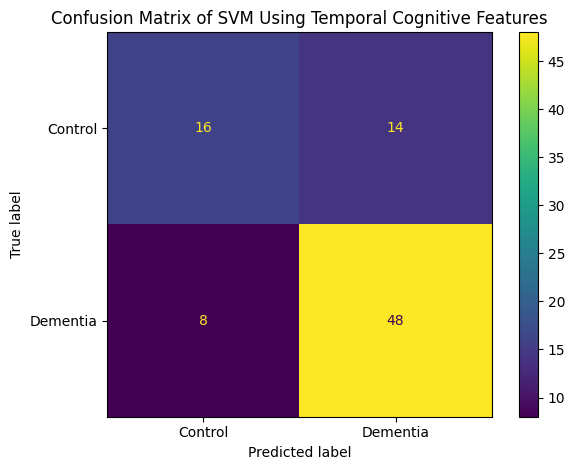

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control", "Dementia"]
)

disp.plot()

plt.title(
    "Confusion Matrix of SVM Using Temporal Cognitive Features"
)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

feature_sets = {
    "Drift": ["Drift"],
    "Consistency": ["Consistency"],
    "Instability": ["Instability"],
    "Breakdown": ["Breakdown"],
    "Drift + Consistency": ["Drift", "Consistency"],
    "Drift + Consistency + Instability": [
        "Drift", "Consistency", "Instability"
    ],
    "All Temporal Features": [
        "Drift", "Consistency", "Instability", "Breakdown"
    ]
}

results = []

for name, feature_list in feature_sets.items():

    X = temporal_df[feature_list]
    y = temporal_df["Label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Feature Set": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

display(results_df)

,Feature Set,Precision,Recall,F1-score,Accuracy,AUC
0,Drift,0.7963,0.7679,0.7818,0.7209,0.6726
1,Consistency,0.7067,0.9464,0.8092,0.7093,0.7158
2,Instability,0.7162,0.9464,0.8154,0.7209,0.7188
3,Breakdown,0.6512,1.0000,0.7887,0.6512,0.2470
4,Drift + Consistency,0.7667,0.8214,0.7931,0.7209,0.7863
5,Drift + Consistency + Instability,0.7541,0.8214,0.7863,0.7093,0.7952
6,All Temporal Features,0.7742,0.8571,0.8136,0.7442,0.7738


In [34]:
results_df.to_excel(
    "Temporal_SVM_Classification_Results.xlsx",
    index=False
)

print("Saved: Temporal_SVM_Classification_Results.xlsx")

Saved: Temporal_SVM_Classification_Results.xlsx


In [35]:
temporal_df["Subject_ID"] = (
    temporal_df["Recording_ID"]
    .str.split("-")
    .str[0]
)

print("Unique recordings:", temporal_df["Recording_ID"].nunique())
print("Unique subjects:", temporal_df["Subject_ID"].nunique())

display(
    temporal_df[
        ["Subject_ID", "Recording_ID", "Label",
         "Drift", "Consistency", "Instability", "Breakdown"]
    ].head(20)
)

Unique recordings: 429
Unique subjects: 267


,Subject_ID,Recording_ID,Label,Drift,Consistency,Instability,Breakdown
0,001,001-0,1,9.050593,0.313891,6.209691,11.896556
1,001,001-2,1,8.505806,0.469163,4.515197,9.778632
2,005,005-0,1,8.300906,0.253128,6.199717,10.055523
3,010,010-0,1,9.092535,0.494035,4.600503,9.949337
4,010,010-1,1,9.645352,0.205371,7.664477,0.000000
5,010,010-2,1,8.712884,0.272663,6.337204,10.353924
6,010,010-4,1,8.286956,0.316302,5.665776,10.218395
7,014,014-2,1,8.180221,1.000000,0.000000,0.000000
8,016,016-0,1,7.673194,0.438812,4.306101,8.997294
9,016,016-1,1,10.124388,0.326922,6.814501,11.549979


In [36]:
# Create participant ID from recording ID

temporal_df["Subject_ID"] = (
    temporal_df["Recording_ID"]
    .astype(str)
    .str.split("-")
    .str[0]
)

print("Unique recordings:", temporal_df["Recording_ID"].nunique())
print("Unique subjects:", temporal_df["Subject_ID"].nunique())

# Show subjects having multiple recordings
multiple = (
    temporal_df.groupby("Subject_ID")
    .size()
    .sort_values(ascending=False)
)

print("\nSubjects with multiple recordings:")
display(multiple[multiple > 1].head(20))

# Show actual examples
display(
    temporal_df[
        ["Subject_ID", "Recording_ID", "Label",
         "Drift", "Consistency", "Instability", "Breakdown"]
    ].head(20)
)

Unique recordings: 429
Unique subjects: 267

Subjects with multiple recordings:


,0
Subject_ID,
033,5
120,5
121,5
058,4
118,4
051,4
010,4
212,4
016,4


,Subject_ID,Recording_ID,Label,Drift,Consistency,Instability,Breakdown
0,001,001-0,1,9.050593,0.313891,6.209691,11.896556
1,001,001-2,1,8.505806,0.469163,4.515197,9.778632
2,005,005-0,1,8.300906,0.253128,6.199717,10.055523
3,010,010-0,1,9.092535,0.494035,4.600503,9.949337
4,010,010-1,1,9.645352,0.205371,7.664477,0.000000
5,010,010-2,1,8.712884,0.272663,6.337204,10.353924
6,010,010-4,1,8.286956,0.316302,5.665776,10.218395
7,014,014-2,1,8.180221,1.000000,0.000000,0.000000
8,016,016-0,1,7.673194,0.438812,4.306101,8.997294
9,016,016-1,1,10.124388,0.326922,6.814501,11.549979


In [37]:
# Create participant ID from recording ID

temporal_df["Subject_ID"] = (
    temporal_df["Recording_ID"]
    .astype(str)
    .str.split("-")
    .str[0]
)

print("Unique recordings:", temporal_df["Recording_ID"].nunique())
print("Unique subjects:", temporal_df["Subject_ID"].nunique())

# Show subjects having multiple recordings
multiple = (
    temporal_df.groupby("Subject_ID")
    .size()
    .sort_values(ascending=False)
)

print("\nSubjects with multiple recordings:")
display(multiple[multiple > 1].head(20))

# Show actual examples
display(
    temporal_df[
        ["Subject_ID", "Recording_ID", "Label",
         "Drift", "Consistency", "Instability", "Breakdown"]
    ].head(20)
)

Unique recordings: 429
Unique subjects: 267

Subjects with multiple recordings:


,0
Subject_ID,
033,5
120,5
121,5
058,4
118,4
051,4
010,4
212,4
016,4


,Subject_ID,Recording_ID,Label,Drift,Consistency,Instability,Breakdown
0,001,001-0,1,9.050593,0.313891,6.209691,11.896556
1,001,001-2,1,8.505806,0.469163,4.515197,9.778632
2,005,005-0,1,8.300906,0.253128,6.199717,10.055523
3,010,010-0,1,9.092535,0.494035,4.600503,9.949337
4,010,010-1,1,9.645352,0.205371,7.664477,0.000000
5,010,010-2,1,8.712884,0.272663,6.337204,10.353924
6,010,010-4,1,8.286956,0.316302,5.665776,10.218395
7,014,014-2,1,8.180221,1.000000,0.000000,0.000000
8,016,016-0,1,7.673194,0.438812,4.306101,8.997294
9,016,016-1,1,10.124388,0.326922,6.814501,11.549979
